In [1]:
# External Import
import torch
from pathlib import Path

from PIL import Image

# Internal Imports
from src.Model.Unet.Unet import UNetModel, predict
from src.Model.persistance import load_weights
from src.Visualization.visualization import visualize_segment_mask

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
model = UNetModel(in_channels=3, out_channels=1)
load_weights(model, Path("../models/unet_2026-03-30_01h03-26s.pth"), device)
model.to(device)

UNetModel(
  (encoder1): Encoder(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.0, inplace=False)
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout2d(p=0.0, inplace=False)
      )
    )
    (max_pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (encoder2): Encoder(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.0, inplace=False)
        (4):

In [3]:
input_img_path = Path("../data/raw/lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_14.tif")
input_mask_path = Path("../data/raw/lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_14_mask.tif")

pred_mask = predict(model, input_img_path, device)

C:\Users\pc\miniconda3\envs\BrainTumorMRIClassification\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


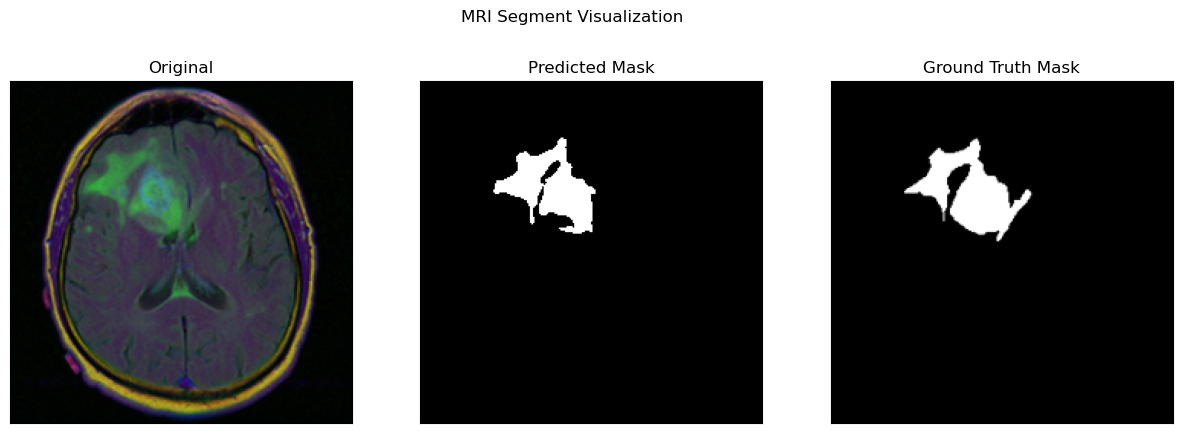

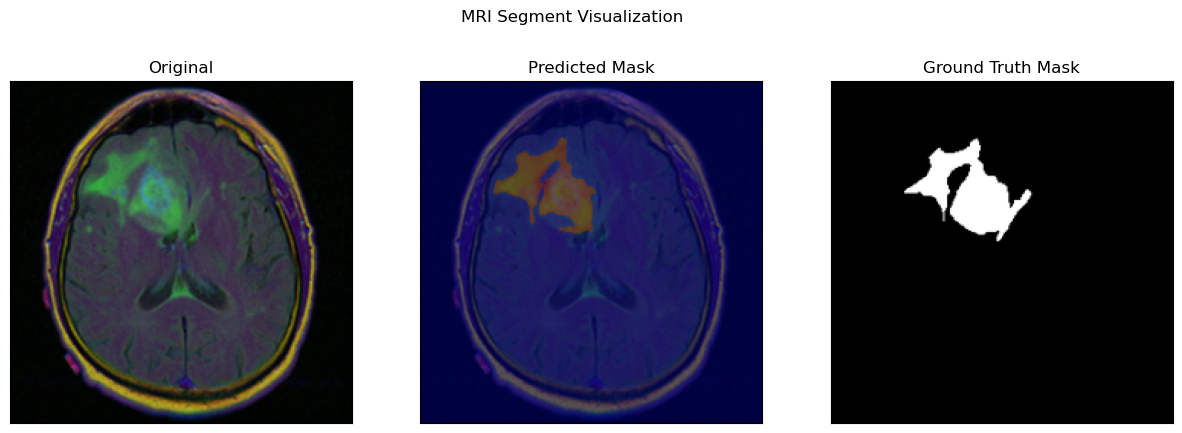

In [4]:
orig_img = Image.open(input_img_path)
ground_truth_mask = Image.open(input_mask_path).convert('L')

visualize_segment_mask(orig_img, pred_mask, ground_truth_mask)
visualize_segment_mask(orig_img, pred_mask, ground_truth_mask, overlaid = True)